<a href="https://colab.research.google.com/github/swaroopchandran015-arch/AIML-Lab/blob/main/AILAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nickkinyae/devops-aws-and-azure-effectiveness-deployment")

print("Path to dataset files:", path)


100%|██████████| 4.12M/4.12M [00:00<00:00, 118MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nickkinyae/devops-aws-and-azure-effectiveness-deployment/versions/1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/nickkinyae/devops-aws-and-azure-effectiveness-deployment/versions/1/DevOps AWS Azure Effectiveness Deployment.csv')
df.head()

,Organization Name,DevOps Efficiency Score,Deployment Time (hours),Resource Usage (GB),AWS Scalability Score,Azure Reliability Score,Cost Efficiency ($),User Feedback Score,Platform Comparison Index,Cloud Integration Effectiveness,Data Security Level,Ethical Compliance,Performance Benchmarking,System Integration Metrics,Operational Flexibility
0,97.280867,27.005785,82.330643,31.176731,99.669022,9.217916,93.016676,45.753412,39.444980,69.066247,41.613356,54.586646,83.254270,61.831494,76.020245
1,50.655977,71.733429,89.419236,78.708647,86.045506,73.141908,30.376261,9.875982,72.470876,52.715741,2.248699,17.474333,86.633175,27.547236,92.945260
2,85.690327,49.673990,16.089223,92.874775,40.071560,19.208071,27.129916,71.582926,18.479459,23.188102,34.671648,92.536787,20.278424,51.455620,74.449163
3,86.962197,47.681079,74.915795,86.126322,36.647329,49.482157,20.459687,85.858965,40.984091,11.226802,82.236712,0.276373,40.798725,24.635338,92.577594
4,50.486453,84.282712,76.790907,17.610578,2.469869,15.461407,82.250081,84.470244,69.485755,37.468774,33.345480,23.768924,91.387704,22.227892,98.849562


In [5]:
df.info()

# Dataset shape

print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Organization Name                50000 non-null  float64
 1   DevOps Efficiency Score          50000 non-null  float64
 2   Deployment Time (hours)          50000 non-null  float64
 3   Resource Usage (GB)              50000 non-null  float64
 4   AWS Scalability Score            50000 non-null  float64
 5   Azure Reliability Score          50000 non-null  float64
 6   Cost Efficiency ($)              50000 non-null  float64
 7   User Feedback Score              50000 non-null  float64
 8   Platform Comparison Index        50000 non-null  float64
 9   Cloud Integration Effectiveness  50000 non-null  float64
 10  Data Security Level              50000 non-null  float64
 11  Ethical Compliance               50000 non-null  float64
 12  Performance Benchm

In [6]:
# Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Data types

print(df.dtypes)

# Missing values

print(df.isnull().sum())

Rows: 50000
Columns: 15
Organization Name                  float64
DevOps Efficiency Score            float64
Deployment Time (hours)            float64
Resource Usage (GB)                float64
AWS Scalability Score              float64
Azure Reliability Score            float64
Cost Efficiency ($)                float64
User Feedback Score                float64
Platform Comparison Index          float64
Cloud Integration Effectiveness    float64
Data Security Level                float64
Ethical Compliance                 float64
Performance Benchmarking           float64
System Integration Metrics         float64
Operational Flexibility            float64
dtype: object
Organization Name                  0
DevOps Efficiency Score            0
Deployment Time (hours)            0
Resource Usage (GB)                0
AWS Scalability Score              0
Azure Reliability Score            0
Cost Efficiency ($)                0
User Feedback Score                0
Platform Comparison I

In [7]:
# First 5 rows

df.head()

# Last 5 rows

df.tail()

# Random 5 rows

df.sample(5)

,Organization Name,DevOps Efficiency Score,Deployment Time (hours),Resource Usage (GB),AWS Scalability Score,Azure Reliability Score,Cost Efficiency ($),User Feedback Score,Platform Comparison Index,Cloud Integration Effectiveness,Data Security Level,Ethical Compliance,Performance Benchmarking,System Integration Metrics,Operational Flexibility
48095,47.114653,63.188561,64.010557,67.236856,20.467282,49.552750,90.206394,71.695370,0.997095,88.292077,54.634743,31.066952,98.690614,42.123444,8.030586
39976,7.831857,90.104206,88.078164,88.260617,47.043018,24.645479,97.102458,80.781281,25.560724,0.928261,27.935085,85.518482,12.222236,27.322759,86.290291
8550,15.719290,63.137011,1.108427,12.151618,37.891876,4.040692,86.080383,78.912291,31.654762,38.127830,67.952695,34.046478,17.415365,37.174325,91.860413
47393,25.062493,47.878464,35.318790,90.224336,17.508482,71.762464,52.034860,92.002079,10.098211,79.031731,89.264636,61.491667,9.346689,23.372668,15.275903
27509,77.594455,7.266926,74.356893,15.741464,21.486730,25.660926,94.629744,94.508719,77.113247,94.167900,88.736432,36.089508,31.171957,71.073072,65.599012


In [8]:
df.isnull().sum()

,0
Organization Name,0
DevOps Efficiency Score,0
Deployment Time (hours),0
Resource Usage (GB),0
AWS Scalability Score,0
Azure Reliability Score,0
Cost Efficiency ($),0
User Feedback Score,0
Platform Comparison Index,0
Cloud Integration Effectiveness,0


In [10]:
# Replace missing numerical values with mean

df.fillna(df.mean(numeric_only=True), inplace=True)

In [11]:
# Replace missing categorical values with mode

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate rows: 0


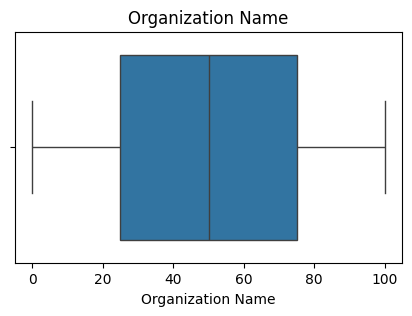

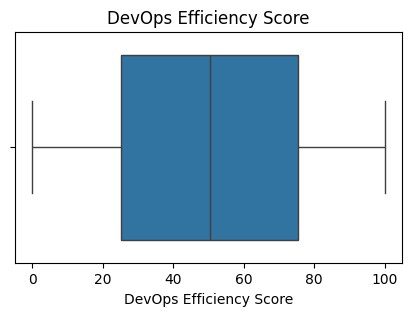

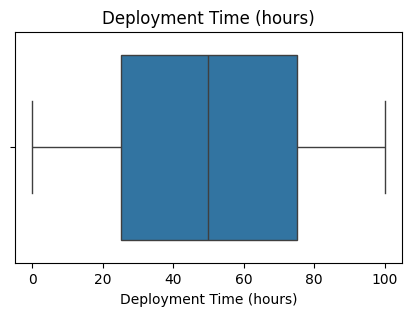

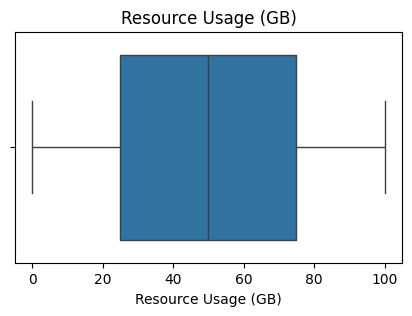

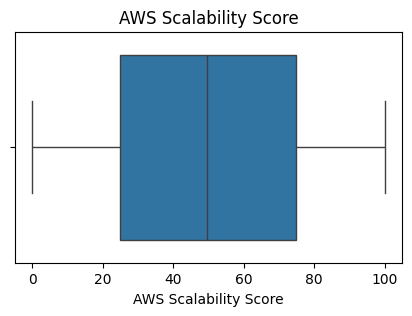

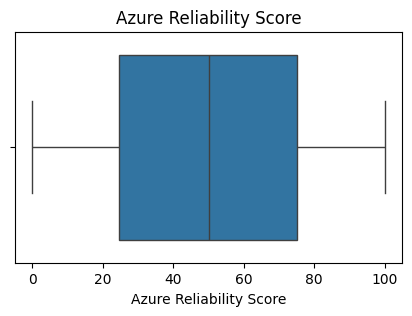

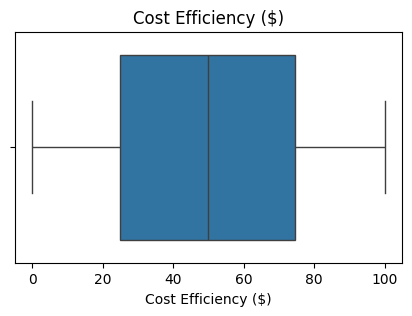

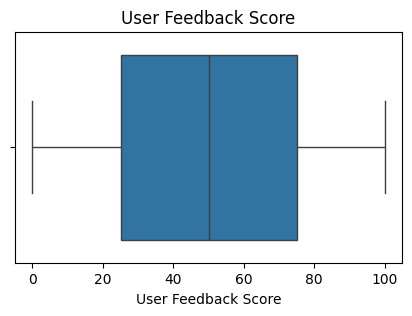

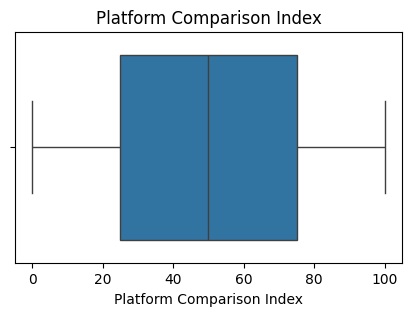

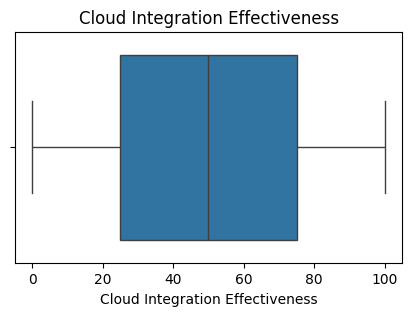

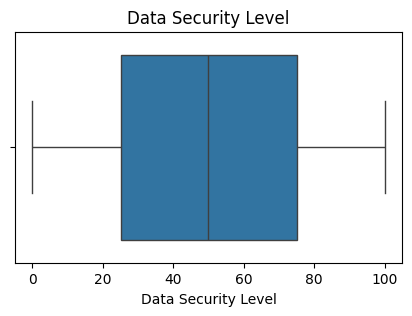

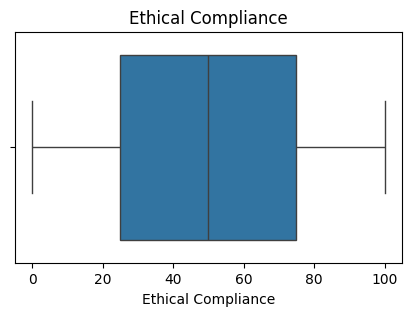

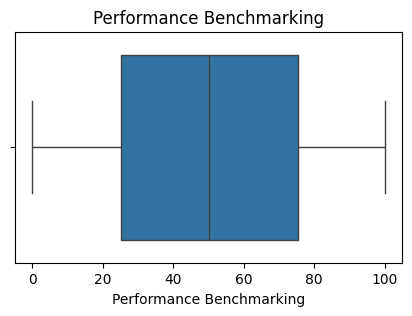

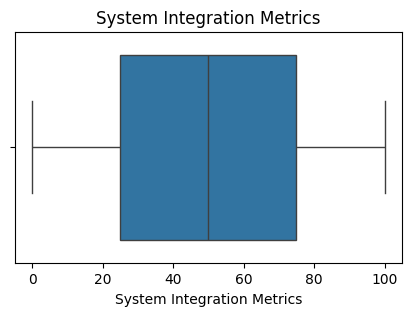

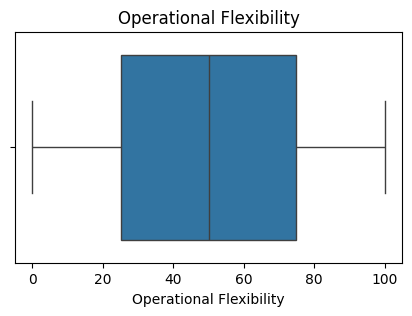

In [13]:
# Select numerical columns

num_cols = df.select_dtypes(include=np.number)

# Draw boxplots

for col in num_cols.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
# Remove outliers using IQR

for col in num_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

df.head()

,Organization Name,DevOps Efficiency Score,Deployment Time (hours),Resource Usage (GB),AWS Scalability Score,Azure Reliability Score,Cost Efficiency ($),User Feedback Score,Platform Comparison Index,Cloud Integration Effectiveness,Data Security Level,Ethical Compliance,Performance Benchmarking,System Integration Metrics,Operational Flexibility
0,97.280867,27.005785,82.330643,31.176731,99.669022,9.217916,93.016676,45.753412,39.444980,69.066247,41.613356,54.586646,83.254270,61.831494,76.020245
1,50.655977,71.733429,89.419236,78.708647,86.045506,73.141908,30.376261,9.875982,72.470876,52.715741,2.248699,17.474333,86.633175,27.547236,92.945260
2,85.690327,49.673990,16.089223,92.874775,40.071560,19.208071,27.129916,71.582926,18.479459,23.188102,34.671648,92.536787,20.278424,51.455620,74.449163
3,86.962197,47.681079,74.915795,86.126322,36.647329,49.482157,20.459687,85.858965,40.984091,11.226802,82.236712,0.276373,40.798725,24.635338,92.577594
4,50.486453,84.282712,76.790907,17.610578,2.469869,15.461407,82.250081,84.470244,69.485755,37.468774,33.345480,23.768924,91.387704,22.227892,98.849562


In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[df.columns] = scaler.fit_transform(df)

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[df.columns] = scaler.fit_transform(df)

In [19]:
correlation = df.corr()

print(correlation)

                                 Organization Name  DevOps Efficiency Score  \
Organization Name                         1.000000                -0.006263   
DevOps Efficiency Score                  -0.006263                 1.000000   
Deployment Time (hours)                   0.008088                -0.000321   
Resource Usage (GB)                       0.005937                -0.003884   
AWS Scalability Score                    -0.003401                 0.002015   
Azure Reliability Score                  -0.006389                 0.000082   
Cost Efficiency ($)                       0.000465                -0.000534   
User Feedback Score                       0.002774                -0.005247   
Platform Comparison Index                -0.001467                -0.003565   
Cloud Integration Effectiveness           0.000474                -0.000730   
Data Security Level                      -0.007120                -0.003980   
Ethical Compliance                       -0.003009  

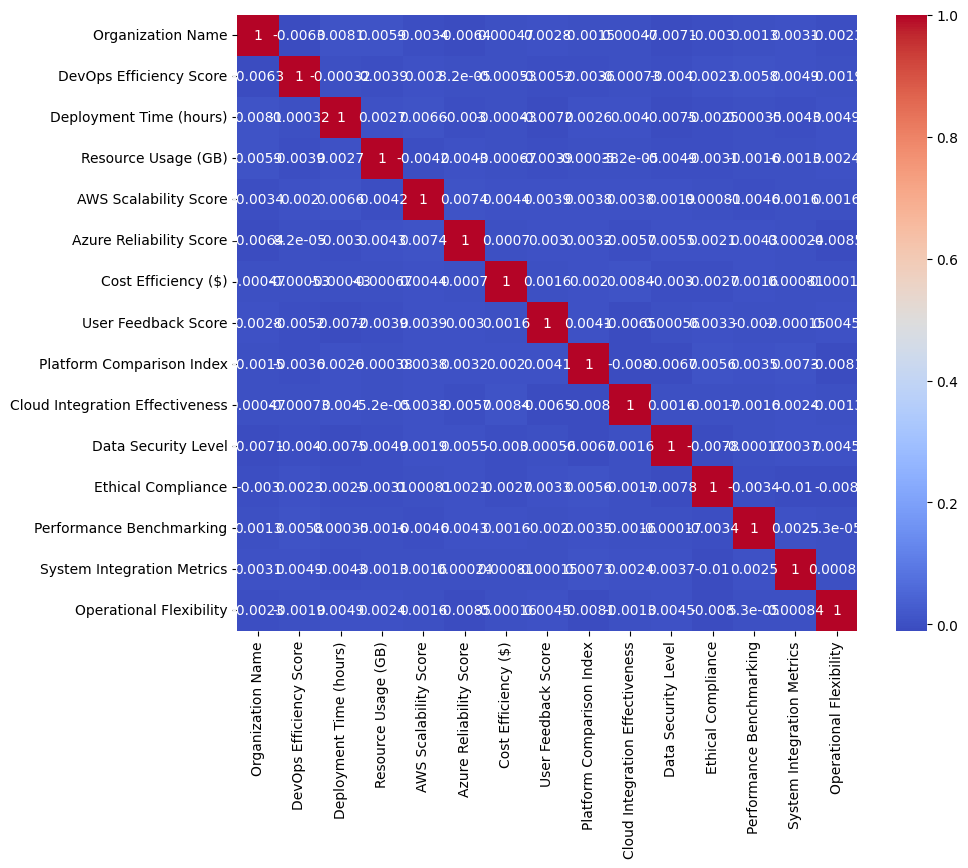

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [21]:
# Create a new feature by adding two numerical columns

df["New_Feature"] = df.iloc[:,0] + df.iloc[:,1]

df.head()

,Organization Name,DevOps Efficiency Score,Deployment Time (hours),Resource Usage (GB),AWS Scalability Score,Azure Reliability Score,Cost Efficiency ($),User Feedback Score,Platform Comparison Index,Cloud Integration Effectiveness,Data Security Level,Ethical Compliance,Performance Benchmarking,System Integration Metrics,Operational Flexibility,New_Feature
0,0.972812,0.270045,0.823308,0.311761,0.996701,0.092139,0.930170,0.457511,0.394435,0.690672,0.416143,0.545876,0.832541,0.618318,0.760219,1.242857
1,0.506558,0.717344,0.894194,0.787087,0.860464,0.731420,0.303763,0.098720,0.724710,0.527164,0.022476,0.174743,0.866331,0.275472,0.929486,1.223903
2,0.856905,0.496739,0.160889,0.928750,0.400719,0.192047,0.271299,0.715818,0.184769,0.231884,0.346722,0.925386,0.202766,0.514558,0.744507,1.353644
3,0.869624,0.476809,0.749159,0.861265,0.366476,0.494807,0.204597,0.858585,0.409827,0.112269,0.822398,0.002759,0.407974,0.246353,0.925809,1.346433
4,0.504863,0.842843,0.767910,0.176097,0.024698,0.154578,0.822503,0.844697,0.694857,0.374692,0.333460,0.237691,0.913877,0.222278,0.988534,1.347707


In [22]:
print(df.dtypes)

Organization Name                  float64
DevOps Efficiency Score            float64
Deployment Time (hours)            float64
Resource Usage (GB)                float64
AWS Scalability Score              float64
Azure Reliability Score            float64
Cost Efficiency ($)                float64
User Feedback Score                float64
Platform Comparison Index          float64
Cloud Integration Effectiveness    float64
Data Security Level                float64
Ethical Compliance                 float64
Performance Benchmarking           float64
System Integration Metrics         float64
Operational Flexibility            float64
New_Feature                        float64
dtype: object


In [23]:
df["New_Feature"] = df["New_Feature"].astype(float)

In [24]:
# Remove leading/trailing spaces

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [25]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]

y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 15)
(10000, 15)


In [26]:
# The SMOTE method is for classification problems with discrete target variables.
# Since 'New_Feature' (y_train) is a continuous variable (float64), SMOTE is not applicable here.
# If you are performing a regression task, this step is not needed.
# If you intend to perform a classification task, you will need to define a categorical target variable.
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

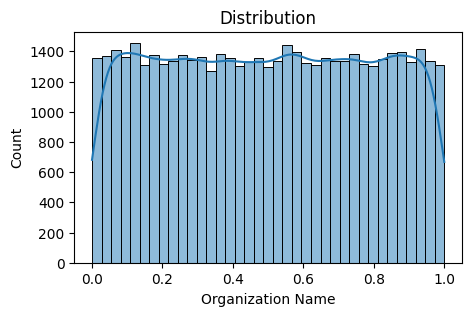

In [27]:
plt.figure(figsize=(5,3))
sns.histplot(df.iloc[:,0], kde=True)
plt.title("Distribution")
plt.show()

In [28]:
print("Final Dataset Shape:", df.shape)

print(df.head())

Final Dataset Shape: (50000, 16)
   Organization Name  DevOps Efficiency Score  Deployment Time (hours)  \
0           0.972812                 0.270045                 0.823308   
1           0.506558                 0.717344                 0.894194   
2           0.856905                 0.496739                 0.160889   
3           0.869624                 0.476809                 0.749159   
4           0.504863                 0.842843                 0.767910   

   Resource Usage (GB)  AWS Scalability Score  Azure Reliability Score  \
0             0.311761               0.996701                 0.092139   
1             0.787087               0.860464                 0.731420   
2             0.928750               0.400719                 0.192047   
3             0.861265               0.366476                 0.494807   
4             0.176097               0.024698                 0.154578   

   Cost Efficiency ($)  User Feedback Score  Platform Comparison Index  \
0  